# Generative Adversarial Networks (GAN)

GAN adalah arsitektur jaringan saraf yang terdiri dari dua komponen utama: **Generator** dan **Discriminator**.  
- **Generator** bertugas membuat data palsu yang menyerupai data asli.  
- **Discriminator** bertugas membedakan antara data asli dan data buatan Generator.  

Keduanya dilatih secara bersamaan dalam permainan minimax:  
- Generator belajar menipu Discriminator  
- Discriminator belajar menjadi lebih baik dalam membedakan  

Tujuannya adalah membuat Generator menghasilkan data yang sangat mirip dengan data asli.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 128

trainset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.30MB/s]


In [3]:
# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [4]:
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
lr = 0.0002

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)


Epoch 1/30 | D Loss: 0.0499 | G Loss: 5.2360
Epoch 2/30 | D Loss: 0.1687 | G Loss: 4.3338
Epoch 3/30 | D Loss: 0.1523 | G Loss: 4.8396
Epoch 4/30 | D Loss: 0.7544 | G Loss: 2.2093
Epoch 5/30 | D Loss: 0.0739 | G Loss: 3.9986


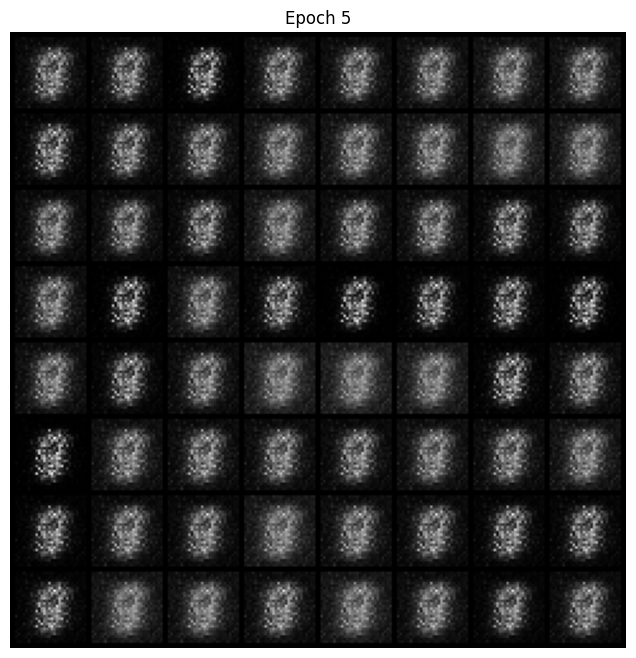

Epoch 6/30 | D Loss: 0.1565 | G Loss: 4.8249
Epoch 7/30 | D Loss: 0.0280 | G Loss: 6.5030
Epoch 8/30 | D Loss: 0.0142 | G Loss: 6.2259
Epoch 9/30 | D Loss: 0.0983 | G Loss: 7.4734
Epoch 10/30 | D Loss: 0.1286 | G Loss: 8.3607


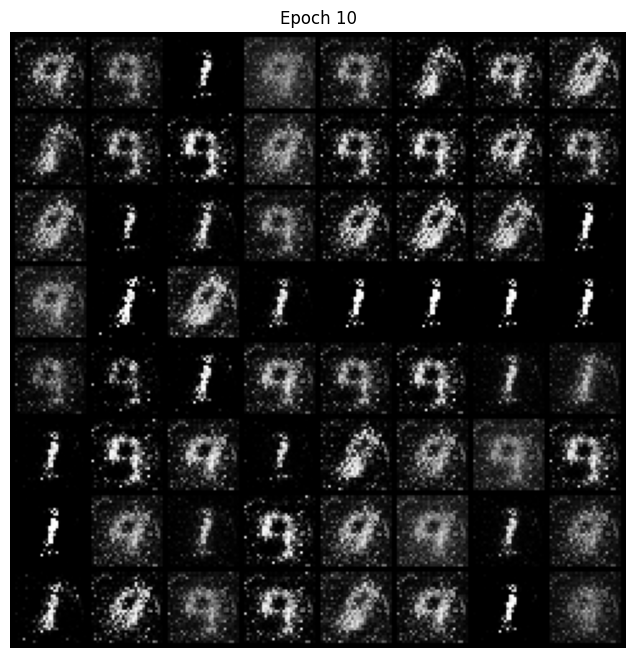

Epoch 11/30 | D Loss: 0.2969 | G Loss: 6.3819
Epoch 12/30 | D Loss: 0.0952 | G Loss: 5.9127
Epoch 13/30 | D Loss: 0.1784 | G Loss: 5.7869
Epoch 14/30 | D Loss: 0.1417 | G Loss: 5.6653
Epoch 15/30 | D Loss: 0.2806 | G Loss: 3.1160


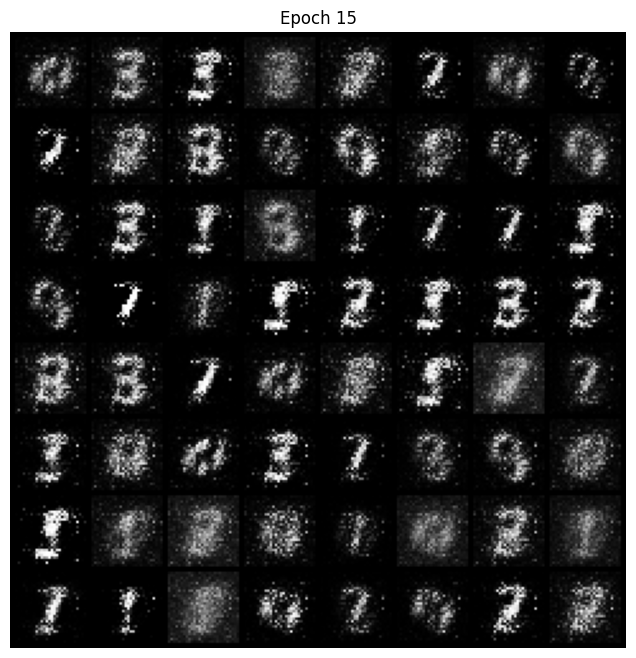

Epoch 16/30 | D Loss: 0.1257 | G Loss: 4.3456
Epoch 17/30 | D Loss: 0.2145 | G Loss: 6.3467
Epoch 18/30 | D Loss: 0.3286 | G Loss: 4.1236
Epoch 19/30 | D Loss: 0.2752 | G Loss: 4.6081
Epoch 20/30 | D Loss: 0.2863 | G Loss: 3.7637


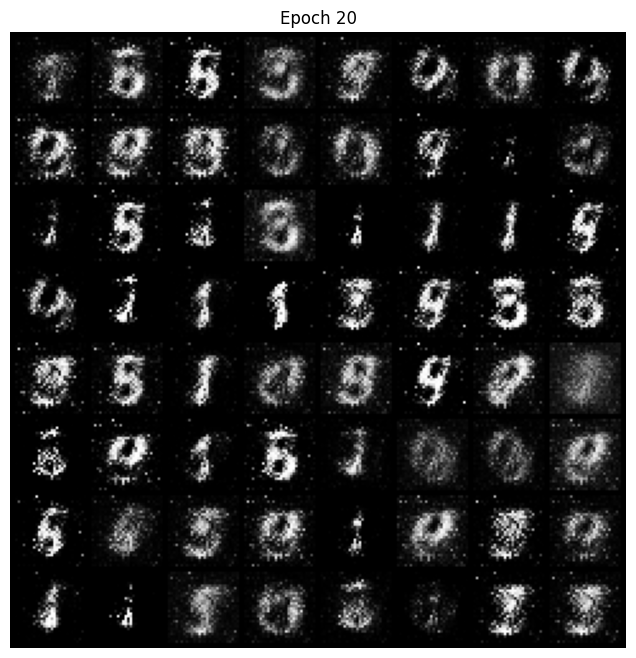

Epoch 21/30 | D Loss: 0.3402 | G Loss: 4.6998
Epoch 22/30 | D Loss: 0.3229 | G Loss: 6.4773
Epoch 23/30 | D Loss: 0.3115 | G Loss: 3.9207
Epoch 24/30 | D Loss: 0.2481 | G Loss: 3.9411
Epoch 25/30 | D Loss: 0.2583 | G Loss: 5.3451


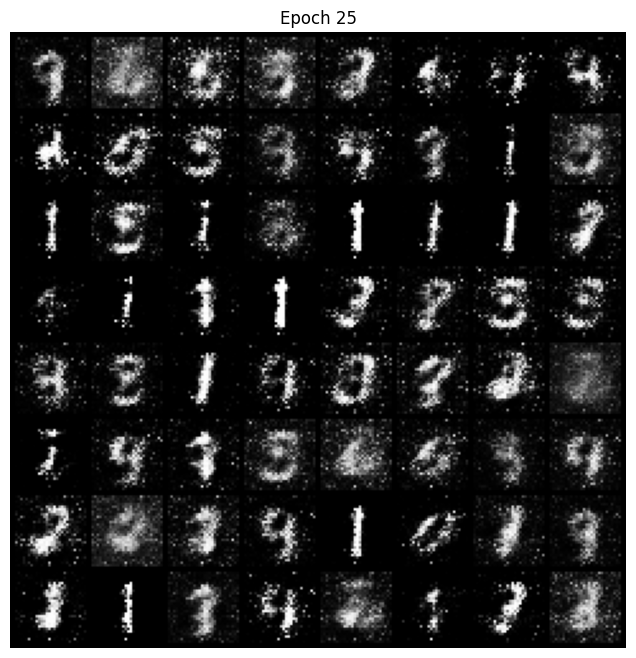

Epoch 26/30 | D Loss: 0.3406 | G Loss: 3.5543
Epoch 27/30 | D Loss: 0.2814 | G Loss: 5.6502
Epoch 28/30 | D Loss: 0.4892 | G Loss: 3.9607
Epoch 29/30 | D Loss: 0.4994 | G Loss: 5.2441
Epoch 30/30 | D Loss: 0.4075 | G Loss: 3.5085


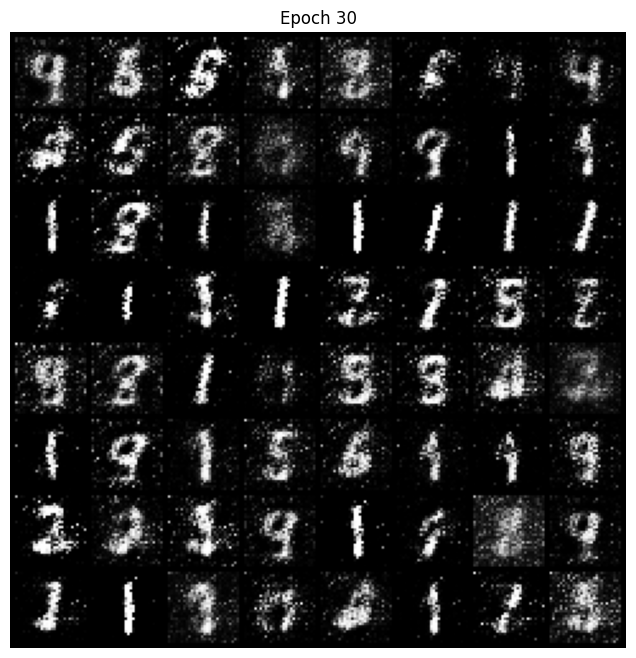

In [5]:
epochs = 30
fixed_noise = torch.randn(64, z_dim).to(device)

for epoch in range(epochs):
    for real, _ in trainloader:
        real = real.to(device)
        batch_size = real.size(0)

        # Label
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        ## Train Discriminator
        z = torch.randn(batch_size, z_dim).to(device)
        fake = G(z)

        D_real = D(real)
        D_fake = D(fake.detach())

        D_loss = loss_fn(D_real, real_labels) + loss_fn(D_fake, fake_labels)
        optimizer_D.zero_grad()
        D_loss.backward()
        optimizer_D.step()

        ## Train Generator
        z = torch.randn(batch_size, z_dim).to(device)
        fake = G(z)
        D_fake = D(fake)
        G_loss = loss_fn(D_fake, real_labels)
        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {D_loss.item():.4f} | G Loss: {G_loss.item():.4f}")

    # Simpan hasil
    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            fake = G(fixed_noise).detach().cpu()
        grid = make_grid(fake, nrow=8, normalize=True)
        plt.figure(figsize=(8,8))
        plt.title(f"Epoch {epoch+1}")
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.show()


In [6]:
torch.save(G.state_dict(), "generator.pth")
torch.save(D.state_dict(), "discriminator.pth")
torch.save(G.state_dict(), "/kaggle/working/generator.pth")
torch.save(D.state_dict(), "/kaggle/working/discriminator.pth")